In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

print(sys.executable)

/home/aviraljoshi/mini-logistic-regression/.venv/bin/python3


In [2]:
# Toy data: 3 tumours, 2 measurements each (radius, texture)
X = np.array([[2, 3],
              [1, 1],
              [4, 2]])
w = np.array([2, 1])   # one weight per measurement
b = -5                 # one shared bias

z = X @ w + b

print("X shape:", X.shape)
print("w shape:", w.shape)
print("z shape:", z.shape)
print("z:", z)

X shape: (3, 2)
w shape: (2,)
z shape: (3,)
z: [ 2 -2  5]


## The number `e` and `e^z`

- **`e ≈ 2.718`** is a mathematical constant, similar to π.
- **`e^z` is always positive**. It can become extremely small, but it never reaches `0` or becomes negative.
  - `e⁻¹⁰ ≈ 0.000045`
- **`e^z` grows extremely fast** as `z` increases.
  - `e¹⁰ ≈ 22,026`
  - `e¹⁰⁰ ≈ 2.69 × 10⁴³`

### Sigmoid function

The **sigmoid function** uses `e^z` to convert any number into a value between `0` and `1`:

`σ(z) = 1 / (1 + e^(-z))`

In NumPy:

```python
1 / (1 + np.exp(-z))

In [3]:
p = 1 / (1 + np.exp(-z))

print("z: ",z)
print("p: ",p)
print("p dtype: ", p.dtype)

z:  [ 2 -2  5]
p:  [0.88079708 0.11920292 0.99330715]
p dtype:  float64


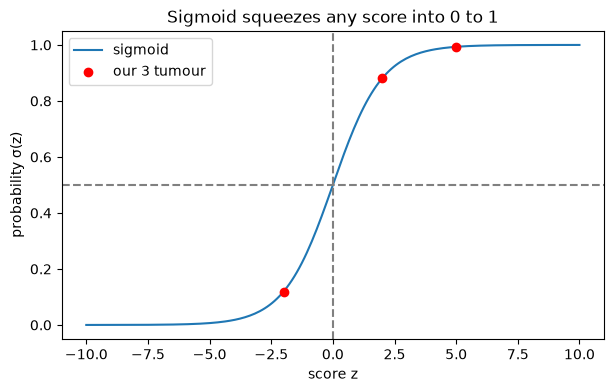

In [4]:
z_range = np.linspace(-10, 10, 200)
p_range = 1 / (1 + np.exp(-z_range))

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(z_range, p_range, label="sigmoid")
ax.scatter(z, p, color="red", zorder=3, label="our 3 tumour")
ax.axhline(0.5, color="gray", linestyle= "--")
ax.axvline(0, color="gray", linestyle= "--")
ax.set_xlabel("Probalities")
ax.set_xlabel("score z")
ax.set_ylabel("probability σ(z)")
ax.set_title("Sigmoid squeezes any score into 0 to 1")
ax.legend()
plt.show()

In [5]:
threshold = 0.5

is_above = p >= threshold
y_pred = is_above.astype(int)

print("is_above:", is_above, is_above.dtype)
print("y_pred:  ", y_pred, y_pred.dtype)

is_above: [ True False  True] bool
y_pred:   [1 0 1] int64


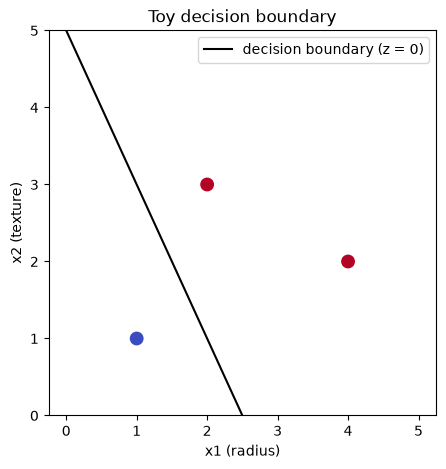

In [6]:
# toy boundary split our 3 tumours?
x1_line = np.linspace(0, 5, 50)
x2_line = -(w[0] * x1_line + b) / w[1]   # from w1*x1 + w2*x2 + b = 0

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(x1_line, x2_line, color="black", label="decision boundary (z = 0)")
ax.scatter(X[:, 0], X[:, 1], c=y_pred, cmap="coolwarm", s=80, zorder=3)
ax.set_ylim(0, 5)
ax.set_xlabel("x1 (radius)")
ax.set_ylabel("x2 (texture)")
ax.set_title("Toy decision boundary")
ax.legend()
plt.show()

## Log-odds

**Log-odds** tells us how strongly the model favors one class over the other.

`log-odds = ln(p / (1 - p))`

For logistic regression:

`z = Xw + b`

and the **log-odds are exactly equal to `z`**.

So:

`z = Xw + b = log-odds`

### The chain works in both directions

**Forward:**

`z → sigmoid → p`

The model starts with `z` and converts it into a probability `p`.

**Backward:**

`p → odds → ln → z`

We can start with the probability, calculate the odds, take the natural logarithm, and get back to `z`.

> **Key idea:** In logistic regression, `z = Xw + b` is not just an intermediate calculation — it represents the **log-odds** of the predicted class.

In [7]:
odds = p / (1 - p)
log_odds = np.log(odds)

print("z:       ", z)
print("odds:    ", odds)
print("log_odds:", log_odds)
print("log_odds equals z?", np.allclose(log_odds, z))

z:        [ 2 -2  5]
odds:     [7.38905610e+00 1.35335283e-01 1.48413159e+02]
log_odds: [ 2. -2.  5.]
log_odds equals z? True


## Combining the two loss rules

We have two rules:

- `y = 1` → `loss = -ln(p)`
- `y = 0` → `loss = -ln(1 - p)`

We could use an `if` statement in code, but there's a neat trick to combine both cases into **one formula**.

The target `y` acts like an **on/off switch**:

`loss = -[y · ln(p) + (1 - y) · ln(1 - p)]`

### When `y = 1`

- `y = 1` keeps the first part: `1 · ln(p)`
- `1 - y = 0` switches off the second part: `0 · ln(1 - p) = 0`
- Therefore: `loss = -ln(p)` ✓

### When `y = 0`

- `y = 0` switches off the first part: `0 · ln(p) = 0`
- `1 - y = 1` keeps the second part: `1 · ln(1 - p)`
- Therefore: `loss = -ln(1 - p)` ✓

> **Key idea:** `y` acts as a switch that automatically selects the correct loss formula for the true class.


In [8]:
y_true = np.array([1, 0, 0])   # pretend labels: tumour 3 is actually benign

per_tumour = -(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))
loss = np.mean(per_tumour)

print("per-tumour loss:", per_tumour)
print("average loss:   ", loss)

per-tumour loss: [0.12692801 0.12692801 5.00671535]
average loss:    1.753523790191694


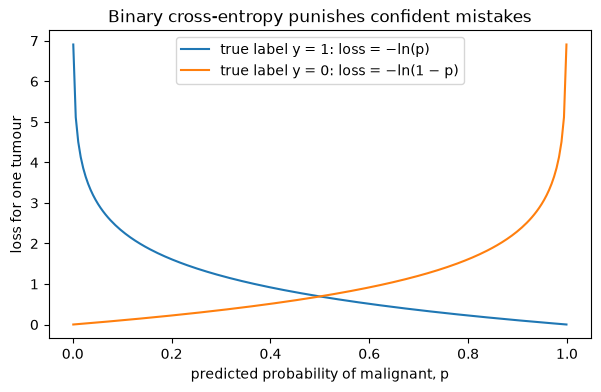

In [9]:
# tumour's loss change as p moves from 0 to 1?
p_grid = np.linspace(0.001, 0.999, 200)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p_grid, -np.log(p_grid), label="true label y = 1: loss = −ln(p)")
ax.plot(p_grid, -np.log(1 - p_grid), label="true label y = 0: loss = −ln(1 − p)")
ax.set_xlabel("predicted probability of malignant, p")
ax.set_ylabel("loss for one tumour")
ax.set_title("Binary cross-entropy punishes confident mistakes")
ax.legend()
plt.show()

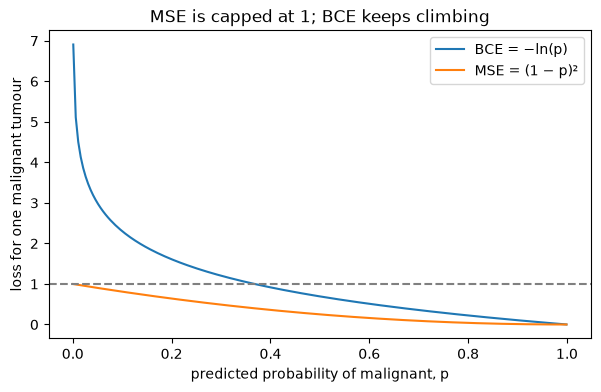

In [10]:
# for a malignant tumour (y = 1), how do MSE and BCE compare?
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p_grid, -np.log(p_grid), label="BCE = −ln(p)")
ax.plot(p_grid, (1 - p_grid) ** 2, label="MSE = (1 − p)²")
ax.axhline(1, color="gray", linestyle="--")
ax.set_xlabel("predicted probability of malignant, p")
ax.set_ylabel("loss for one malignant tumour")
ax.set_title("MSE is capped at 1; BCE keeps climbing")
ax.legend()
plt.show()

## Gradients for Logistic Regression

The gradient tells us **how much each parameter (`w` and `b`) should change** to reduce the loss.

### Weight gradient

`∂L/∂wⱼ = (1/n) Σᵢ (pᵢ − yᵢ) · xᵢⱼ`

This tells us how the loss changes with respect to weight `wⱼ`.

### Bias gradient

`∂L/∂b = (1/n) Σᵢ (pᵢ − yᵢ)`

This tells us how the loss changes with respect to the bias `b`.

### Key idea

Both gradients are based on the same quantity:

`pᵢ − yᵢ`

This is the **prediction error**:

- `pᵢ > yᵢ` → prediction is too high
- `pᵢ < yᵢ` → prediction is too low
- `pᵢ = yᵢ` → no prediction error

For the weight, the error is also multiplied by the feature value `xᵢⱼ`.

> **Remember:**  
> **Gradient = direction and amount of change needed to reduce the loss.**

In [11]:
# calculating gradient

n = len(y_true)
error = p - y_true

grad_w = X.T @ error / n
grad_b = np.mean(error)

print("error: ", error)
print("grad_w:", grad_w, grad_w.shape)
print("grad_b:", grad_b)

error:  [-0.11920292  0.11920292  0.99330715]
grad_w: [1.28467522 0.58273615] (2,)
grad_b: 0.33110238302523837


In [12]:
def toy_loss(w, b):
    p = 1 / (1 + np.exp(-(X @ w + b)))
    return np.mean(-(y_true * np.log(p) + (1 - y_true) * np.log(1 - p)))

eps = 1e-6
w_nudged = w.astype(float)
w_nudged[0] = w_nudged[0] + eps

numeric = (toy_loss(w_nudged, b) - toy_loss(w, b)) / eps
print("from formula:", grad_w[0])
print("from nudging:", numeric)

from formula: 1.2846752247602478
from nudging: 1.284675319901396


In [13]:
# simple sigmoid overflow
def naive_sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_extreme = np.array([-1000.0, -710.0, -5.0, 0.0, 5.0, 1000.0])
print(naive_sigmoid(z_extreme))

[0.         0.         0.00669285 0.5        0.99330715 1.        ]


/tmp/ipykernel_4175/4052453224.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


## Handling overflow in the sigmoid

The standard sigmoid formula is:

`σ(z) = 1 / (1 + e^(-z))`

The problem is that `np.exp()` can **overflow** when its input becomes very large.

To avoid this, we use **two mathematically equivalent formulas** depending on the value of `z`.

### When `z >= 0`

`σ(z) = 1 / (1 + e^(-z))`

Here, `-z` is zero or negative, so `e^(-z)` is never extremely large.

### When `z < 0`

`σ(z) = e^z / (1 + e^z)`

Here, `z` is negative, so `e^z` is small and cannot overflow.

### In short

```text
z >= 0  →  σ(z) = 1 / (1 + e^(-z))
z < 0   →  σ(z) = e^z / (1 + e^z)

In [14]:
# stable sigmoid, so exp only ever sees zero or negative numbers
def stable_sigmoid(z):
    e = np.exp(-np.abs(z))
    return np.where(z >= 0, 1 / (1 + e), e / (1 + e))

print(stable_sigmoid(z_extreme))

[0.00000000e+000 4.47628623e-309 6.69285092e-003 5.00000000e-001
 9.93307149e-001 1.00000000e+000]


In [15]:
# simple BCE break when p is exactly 0 or 1

def naive_bce(y, p):
    return -(y*np.log(p) + (1-y)*np.log(1-p))

y_check = np.array([1.0, 0.0, 1.0])
p_check = np.array([0.0, 1.0, 1.0])
print(naive_bce(y_check, p_check))

[inf inf nan]


/tmp/ipykernel_4175/4263863004.py:4: RuntimeWarning: divide by zero encountered in log
  return -(y*np.log(p) + (1-y)*np.log(1-p))
/tmp/ipykernel_4175/4263863004.py:4: RuntimeWarning: invalid value encountered in multiply
  return -(y*np.log(p) + (1-y)*np.log(1-p))


In [16]:
# clip p away from exactly 0 and 1 before the log
def safe_bce(y, p, eps=1e-15):
    p = np.clip(p, eps, 1 - eps)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))

print(safe_bce(y_check, p_check))

[3.45387764e+01 3.45395760e+01 9.99200722e-16]


In [17]:
from mini_lr.logistic_regression import sigmoid
print(sigmoid(z_extreme))

[0.00000000e+000 4.47628623e-309 6.69285092e-003 5.00000000e-001
 9.93307149e-001 1.00000000e+000]
